<a href="https://colab.research.google.com/github/Cxris2145/MineriaDatos2026/blob/main/ExportacionesChile2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://www.kaggle.com/datasets/michallublin/chile-export-products-20172021

https://github.com/UXDynamicSolution/MineriaDatosDuocPAO/blob/main/eda_ejercicio.ipynb

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [2]:
# Para ver todas las columnas sin cortes
pd.set_option('display.max_columns', None)

# Para ver todas las filas
pd.set_option('display.max_rows', None)


In [17]:
df = pd.read_csv("ChileExport.csv", sep=';')
df.head()

,Country,1 category,2 category,Product,Year,Income in USD
0,China,Minero,Minería,Minerales de cobre y sus concentrados,2017,6470444174
1,China,Minero,Minería,Cobre,2017,7604230274
2,China,Minero,Minería,Minerales de hierro y sus concentrados,2017,"616711446,1"
3,China,Minero,Minería,Litio,2017,234218255
4,China,Minero,Minería,Minerales de molibdeno y sus concentrados,2017,"37490057,93"


In [4]:
df_anio = df["Year"].describe()
print(df_anio)

count    21385.000000
mean      2019.000000
std          1.414247
min       2017.000000
25%       2018.000000
50%       2019.000000
75%       2020.000000
max       2021.000000
Name: Year, dtype: float64


In [5]:
# Cuenta en cuántas filas (registros de exportación) aparece cada país de destino.
# Chile tuvo más transacciones o diversidad de productos exportados entre 2017 y 2021.

df_country = df["Country"].value_counts()
print(df_country)

Country
Estados Unidos de América                              355
China                                                  350
Japón                                                  335
Perú                                                   335
Brasil                                                 330
Canadá                                                 330
España                                                 330
Alemania                                               315
Colombia                                               315
México                                                 310
Holanda                                                305
Corea del Sur                                          305
Italia                                                 300
Reino Unido                                            295
Argentina                                              295
Bélgica                                                280
Ecuador                                         

In [6]:
df_country = df["1 category"].value_counts()
print(df_country)

1 category
No minero      19505
Minero          1865
(en blanco)       15
Name: count, dtype: int64


In [7]:
df_country = df["2 category"].value_counts()
print(df_country)

2 category
Frutas y frutos                                     5440
Otros alimentos                                     3345
Productos del mar                                   2855
Forestales y sus derivados                          2150
Otros productos relevantes                          2040
Minería                                             1865
Vitivinícola                                        1815
Resto No minería                                    1060
Exportación de servicios calificados por Aduanas     800
(en blanco)                                           15
Name: count, dtype: int64


In [8]:
df_country = df["Product"].value_counts()
print(df_country)

Product
Resto No minería                                    1060
Vinos                                                840
Exportación de servicios calificados por Aduanas     800
Madera y sus manufacturas                            645
Resto Forestales y sus derivados                     620
Papel y cartón y sus manufacturas                    605
Uvas                                                 600
Conservas y preparaciones de pescados y mariscos     590
Resto Otros alimentos                                590
Vinos espumosos                                      580
Manzanas                                             500
Ciruelas                                             490
Salmones y truchas                                   470
Nueces de nogal                                      460
Medicamentos                                         445
Kiwis                                                410
Resto Frutas y frutos                                395
Mostos de uva          

In [9]:
df.tail()

,Country,1 category,2 category,Product,Year,Income in USD
21380,Gambia,No minero,Exportación de servicios calificados por Aduanas,Exportación de servicios calificados por Aduanas,2021,0
21381,Gambia,No minero,Resto No minería,Resto No minería,2021,0
21382,Groenlandia,No minero,Resto No minería,Resto No minería,2021,0
21383,República de Yemen,No minero,Resto No minería,Resto No minería,2021,0
21384,Timor Oriental,No minero,Resto No minería,Resto No minería,2021,0


In [10]:
df.shape

(21385, 6)

In [11]:
df.dtypes

,0
Country,object
1 category,object
2 category,object
Product,object
Year,int64
Income in USD,object


In [12]:
df.isnull().sum()

,0
Country,0
1 category,0
2 category,0
Product,0
Year,0
Income in USD,0


In [13]:
df.columns

Index(['Country', '1 category', '2 category', 'Product', 'Year',
       'Income in USD'],
      dtype='object')

In [14]:
# Revisamos si hay filas duplicadas en el dataset (datos repetidos)
df.duplicated().sum()

# Eliminamos duplicados si existen
df = df.drop_duplicates()

In [18]:
# Limpiamos los nombres de columnas por si tienen espacios raros
df.columns = df.columns.str.strip()

In [19]:
# Contamos cuántas exportaciones son mineras vs no mineras
df['1 category'].value_counts()

,count
1 category,
No minero,19505
Minero,1865
(en blanco),15


In [40]:
# Esta función sirve para poner los valores encima de cada barra del gráfico
def agregar_valores(ax):
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom')

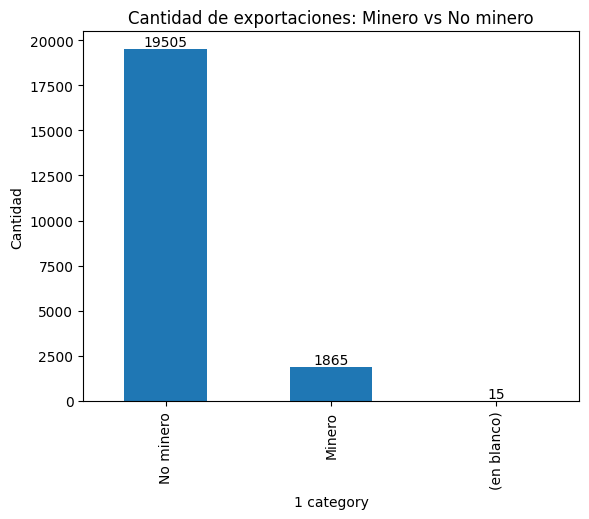

In [50]:
# Este gráfico sirve para ver de forma rápida cuántas exportaciones son de minería
# y cuántas no. Básicamente nos deja claro cuál aparece más en los datos.

ax = df['1 category'].value_counts().plot(kind='bar')

import matplotlib.pyplot as plt
plt.title("Cantidad de exportaciones: Minero vs No minero")
plt.ylabel("Cantidad")

agregar_valores(ax)

plt.show()

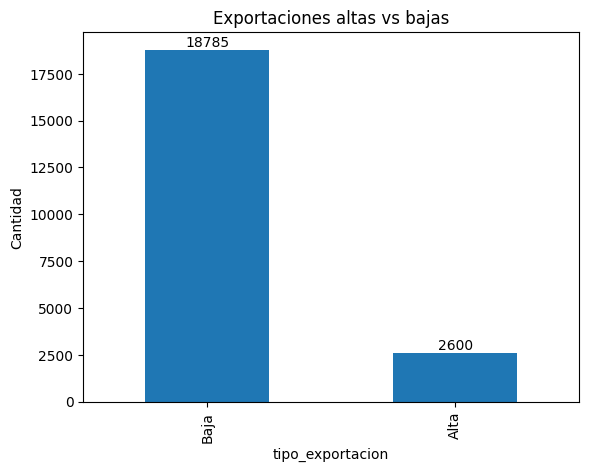

In [51]:
# Aquí estamos separando las exportaciones en dos grupos: las que tienen mucho dinero
# y las que tienen menos. Este gráfico ayuda a ver cómo se reparten.

ax = df['tipo_exportacion'].value_counts().plot(kind='bar')

import matplotlib.pyplot as plt
plt.title("Exportaciones altas vs bajas")
plt.ylabel("Cantidad")

agregar_valores(ax)

plt.show()

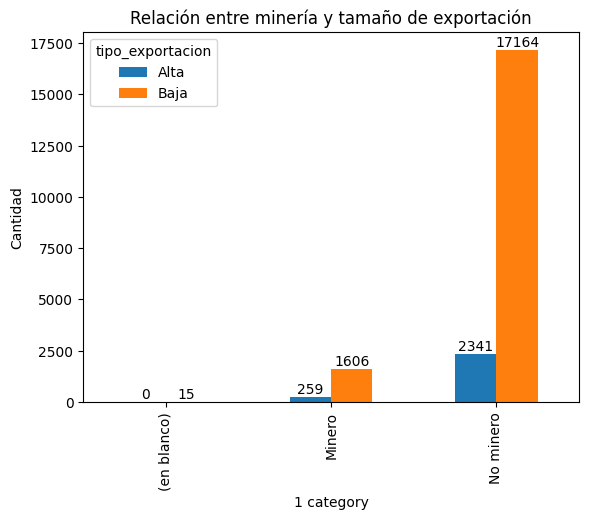

In [52]:
# Este gráfico mezcla dos cosas: si es minería o no, y si es una exportación grande o chica.
# Sirve para ver claramente si la minería está asociada a exportaciones más grandes.

ax = pd.crosstab(df['1 category'], df['tipo_exportacion']).plot(kind='bar')

import matplotlib.pyplot as plt
plt.title("Relación entre minería y tamaño de exportación")
plt.ylabel("Cantidad")

agregar_valores(ax)

plt.show()

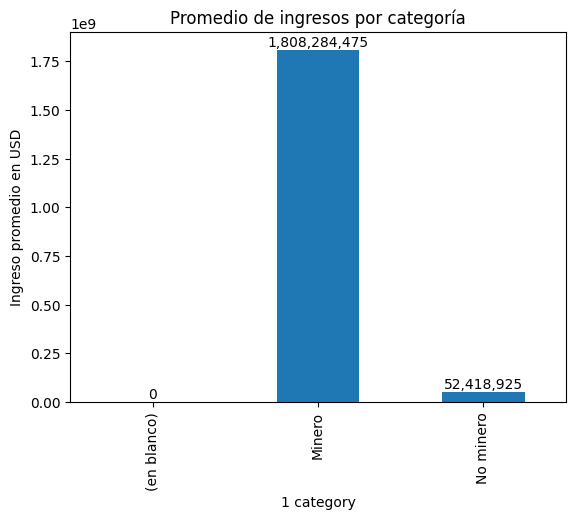

In [53]:
# Aquí vemos cuánto dinero genera en promedio cada tipo de exportación.
# Esto es importante porque no importa solo cuántas hay, sino cuánto dinero dejan.

ax = df.groupby('1 category')['Income in USD'].mean().plot(kind='bar')

import matplotlib.pyplot as plt
plt.title("Promedio de ingresos por categoría")
plt.ylabel("Ingreso promedio en USD")

for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')

plt.show()

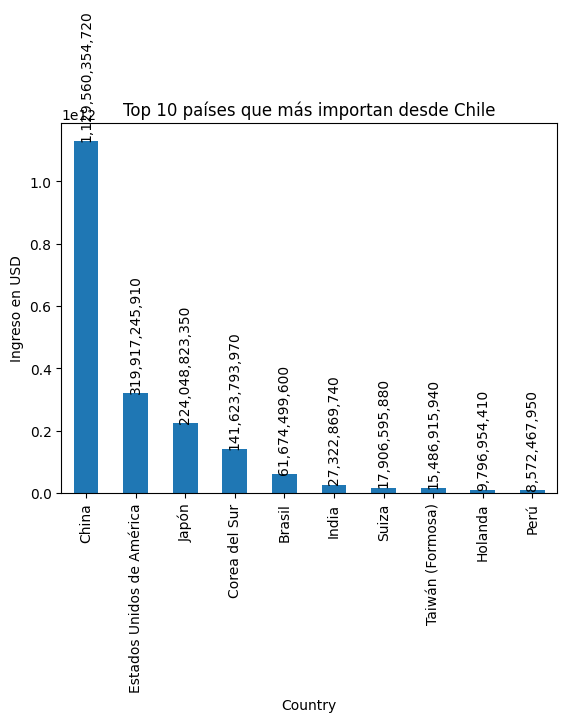

In [54]:
# Este gráfico muestra qué países compran más a Chile.
# Sirve para entender hacia dónde se están yendo las exportaciones más importantes.

top_paises = df.groupby('Country')['Income in USD'].sum().sort_values(ascending=False).head(10)

ax = top_paises.plot(kind='bar')

import matplotlib.pyplot as plt
plt.title("Top 10 países que más importan desde Chile")
plt.ylabel("Ingreso en USD")

for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', rotation=90)

plt.show()

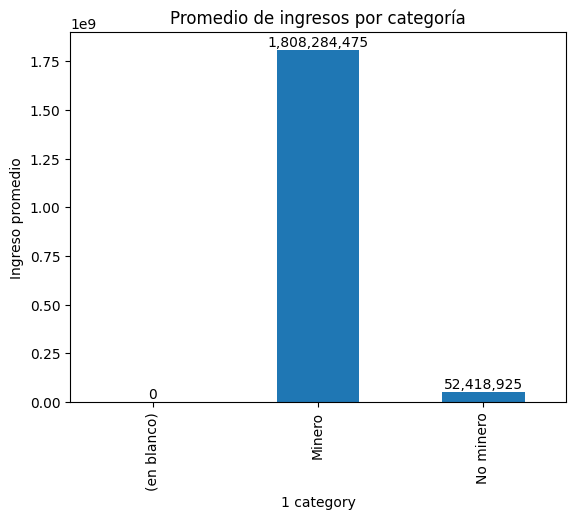

In [46]:
# Promedio de ingresos con valores visibles
ax = df.groupby('1 category')['Income in USD'].mean().plot(kind='bar')

import matplotlib.pyplot as plt
plt.title("Promedio de ingresos por categoría")
plt.ylabel("Ingreso promedio")

# Aquí usamos formato con separador de miles
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')

plt.show()